<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="images/upct.png" alt="UPCT" style="height:45px; width:auto;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="images/umu.png" alt="UMU" style="height:45px; width:auto;">
</div>

___
### **Sesión 11**
## Aprendizaje Automático en Procesamiento de Imágenes

___

### Objetivos
- Comprender la **relevancia del aprendizaje automático** en el procesamiento de imágenes.
- Aplicar **técnicas de correlación** para la detección de patrones y características en imágenes.
- Implementar y evaluar métodos de **aprendizaje no supervisado**, como PCA y clustering, para analizar y agrupar datos de imágenes.
- Utilizar algoritmos de **aprendizaje supervisado** para la clasificación y mejora de la resolución de imágenes.

### Contenidos
- [Revisión de Conceptos](#conceptos12)
- [Búsqueda de Patrones por Correlación](#correlacion12)
- [Aprendizaje No Supervisado](#nosupervisado12)
- [Aprendizaje Supervisado](#supervisado12)
- [Ejercicios de práctica](#ejercicios12)


<div style="page-break-before: always;"></div>

___
 <a class='anchor' id='conceptos12'></a>
 
## Revisión de Conceptos

<div style="display:flex; justify-content:space-around; align-items:center;">
    <img src="images/ai_ml_dl.png" style="width:30%; height:auto;">
</div>
<p style="text-align: center;">Inteligencia Artificial vs. Aprendizaje Automático vs. Aprendizaje Profundo</p>
<br>

### *Configuración del Entorno*

En esta última práctica necesitaremos instalar una biblioteca especializada en aprendizaje profundo que no hemos utilizado hasta ahora. Para hacerlo, activa tu entorno `prim` y ejecuta el siguiente comando:

```bash
    micromamba activate prim
    (prim) pip install tensorflow
```


<div style="page-break-before: always;"></div>

___
 <a class='anchor' id='correlacion12'></a>

## Búsqueda de Patrones por Correlación

La búsqueda de patrones por correlación ([template matching](https://en.wikipedia.org/wiki/Template_matching)) es una técnica muy utilizada en el procesamiento de imágenes y visión por computadora, que se utiliza para identificar y localizar patrones o características específicas dentro de una imagen. Esta técnica consiste en comparar una plantilla (un patrón de referencia) con diferentes secciones de una imagen más grande para encontrar las coincidencias más fuertes. La correlación evalúa la similitud entre la plantilla y las regiones de la imagen, generando un mapa de correlación donde los picos indican áreas de alta similitud. El siguiente bloque de código muestra su implementación.

Tiempo de ejecución: 58.78 segundos


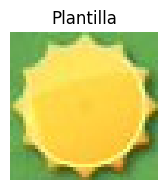

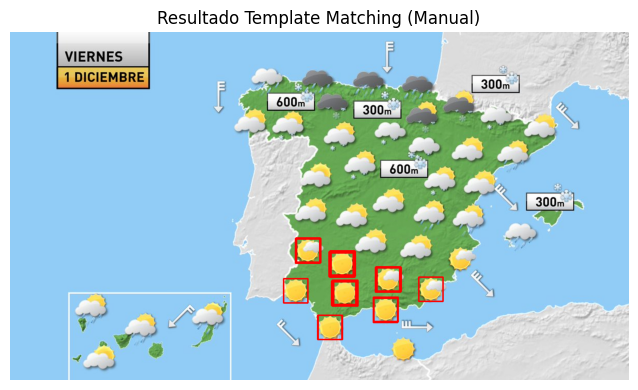

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

def normalized_cross_correlation(image, template):
    """
    Realiza la coincidencia de plantillas usando la correlación cruzada normalizada.
    """
    # Obtener dimensiones de la imagen y la plantilla
    image_h, image_w = image.shape
    template_h, template_w = template.shape
    
    # Inicializar el resultado
    result = np.zeros((image_h - template_h + 1, image_w - template_w + 1))

    # Realizar la correlación cruzada normalizada manualmente
    for y in range(image_h - template_h + 1):
        for x in range(image_w - template_w + 1):
            # Extraer la región de interés de la imagen
            roi = image[y:y + template_h, x:x + template_w]
            # Calcular la media de la ROI y la plantilla
            mean_roi = np.mean(roi)
            mean_template = np.mean(template)
            # Calcular la desviación estándar de la ROI y la plantilla
            std_roi = np.std(roi)
            std_template = np.std(template)
            # Evitar división por cero
            if std_roi == 0 or std_template == 0:
                result[y, x] = 0
            else:
                # Calcular la correlación cruzada normalizada
                ncc = np.sum((roi - mean_roi) * (template - mean_template)) / (std_roi * std_template * template.size)
                result[y, x] = ncc

    return result

# Cargar la imagen principal y la plantilla
image = cv2.imread('images/mapa.jpg')
template = cv2.imread('images/sol.jpg')

# Convertimos a RGB para visualizar con matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
template_rgb = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)

# Convertir las imágenes a escala de grises
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

# Aplicar el método de coincidencia de plantillas manualmente
time_start = time.time()
result = normalized_cross_correlation(image_gray, template_gray)
time_end = time.time()
print('Tiempo de ejecución: {:.2f} segundos'.format(time_end - time_start))

# Definir un umbral para considerar una coincidencia
threshold = 0.75
ys, xs = np.where(result >= threshold) # coordenadas de las coincidencias

# Obtener las dimensiones de la plantilla
w, h = template.shape[0:2]

# Copiar la imagen RGB para dibujar los rectángulos
image_rgb1 = image_rgb.copy()

# Dibujar rectángulos alrededor de todas las coincidencias
for x, y in zip(xs, ys):
    top_left = (x, y)
    bottom_right = (x + w, y + h)
    cv2.rectangle(image_rgb1, top_left, bottom_right, (255, 0, 0), 2)

# Mostrar la imagen de la plantilla
plt.figure(figsize=(2, 2))
plt.imshow(template_rgb); plt.title('Plantilla'); plt.axis('off')
plt.tight_layout()
plt.show()

# Mostrar la imagen resultante con las coincidencias marcadas
plt.figure(figsize=(8, 4))
plt.imshow(image_rgb1); plt.title('Resultado Template Matching (Manual)'); plt.axis('off')
plt.tight_layout()
plt.show()

La función `normalized_cross_correlation` calcula la correlación entre la plantilla y todas las regiones de la imagen, obteniendo un mapa de similitud que se utiliza para detectar coincidencias al superar un umbral predefinido. Como podemos observar, el resultado obtenido no es perfecto, presentando falsos positivos y negativos, además de múltiples detecciones muy cercanas para una misma coincidencia debido al margen establecido por el umbral. El coste computacional de utilizar un doble bucle para el cálculo del mapa de correlación es también muy elevado. Afortunadamente, *OpenCV* implementa estas operaciones de forma mucho más eficiente y ofrece una función de supresión de no máximos para eliminar detecciones redundantes.

Tiempo de ejecución: 0.03 segundos


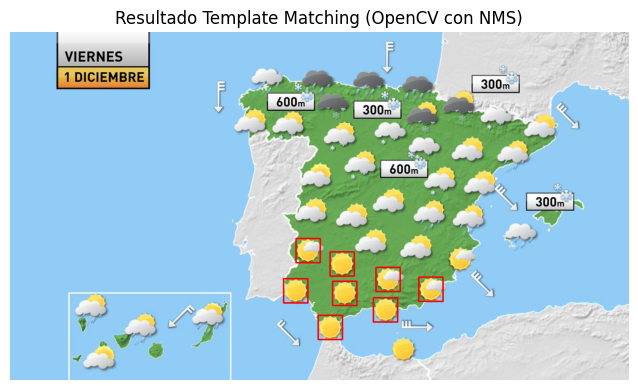

In [3]:
# Copiar la imagen original
image_rgb2 = image_rgb.copy()

# Aplicar el método de coincidencia de plantillas de OpenCV
time_start2 = time.time()
result2 = cv2.matchTemplate(image_gray, template_gray, cv2.TM_CCOEFF_NORMED)
time_end2 = time.time()
print('Tiempo de ejecución: {:.2f} segundos'.format(time_end2 - time_start2))

# Buscar coincidencias con el umbral definido anteriormente
ys, xs = np.where(result2 >= threshold)

# Crear una lista de las cajas delimitadoras y sus scores
boxes = []
scores = []
for x, y in zip(xs, ys):
    boxes.append([x, y, w, h])
    scores.append(result2[y, x])

# Aplicar la supresión de no máximos
indices = cv2.dnn.NMSBoxes(boxes, scores, score_threshold=threshold, nms_threshold=0.3)

# Dibujar rectángulos alrededor de las coincidencias después de la supresión de no máximos
for i in indices:
    box = boxes[i]
    top_left = (box[0], box[1])
    bottom_right = (box[0] + box[2], box[1] + box[3])
    cv2.rectangle(image_rgb2, top_left, bottom_right, (255, 0, 0), 2)

# Mostrar la imagen resultante con las coincidencias marcadas
plt.figure(figsize=(8, 4))
plt.imshow(image_rgb2)
plt.title('Resultado Template Matching (OpenCV con NMS)')
plt.axis('off')
plt.tight_layout()
plt.show()

<div style="page-break-before: always;"></div>

___
 <a class='anchor' id='nosupervisado12'></a>
 
## Aprendizaje No Supervisado

El [aprendizaje no supervisado](https://en.wikipedia.org/wiki/Supervised_learning) es una metodología fundamental en el procesamiento de imágenes ya que permite descubrir patrones y estructuras ocultas en los datos sin la necesidad de etiquetas predefinidas. En las próximas secciones, se explorarán dos métodos muy importantes: el Análisis de Componentes Principales (PCA) y el agrupamiento (clustering).

### Análisis de Componentes Principales (PCA)

El Análisis de Componentes Principales ([PCA](https://en.wikipedia.org/wiki/Principal_component_analysis)) es una técnica de reducción de dimensionalidad que transforma los datos originales en un nuevo conjunto de variables ortogonales llamadas *componentes principales*. Estas componentes capturan la mayor parte de la variabilidad presente en los datos, permitiendo representar la información esencial con menos dimensiones. En el caso particular de las imágenes, donde todas las características corresponden a intensidades de píxel dentro de la misma escala, no suele existir sesgo de magnitud entre variables, por lo que PCA puede aplicarse directamente sin necesidad de estandarizar los datos. A continuación, veremos un ejemplo de su uso.

Forma de los datos: (1797, 64)


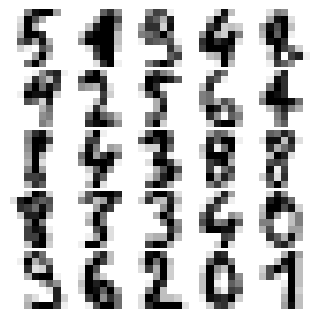

Varianza explicada acumulada: 0.29


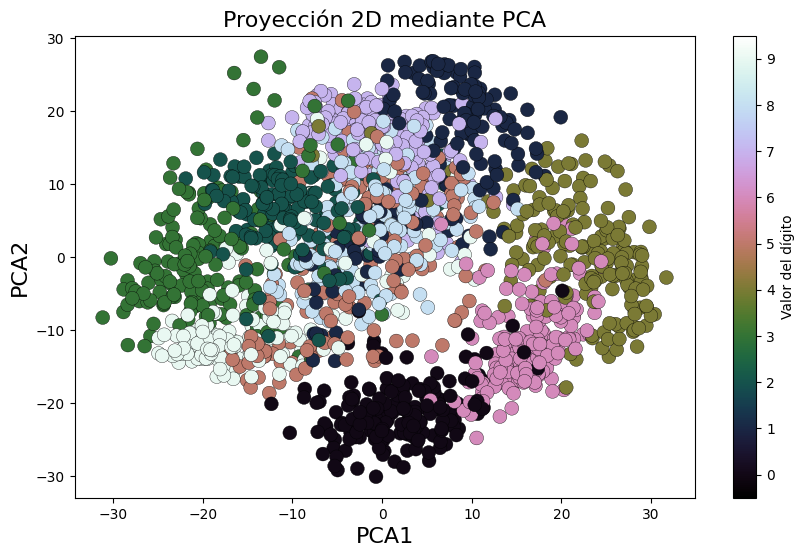

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# Cargar el conjunto de datos de dígitos
digits = load_digits()

# Imprimir la forma de los datos
print("Forma de los datos:", digits.data.shape)

# Establecer una semilla para la reproducibilidad
np.random.seed(1)

# Crear una figura para visualizar algunas imágenes de dígitos
fig = plt.figure(figsize=(3, 3))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# Seleccionar 25 imágenes aleatorias y mostrarlas
for i, idx in enumerate(np.random.choice(digits.data.shape[0], 25), start=1):
    ax = fig.add_subplot(5, 5, i)
    ax.imshow(np.reshape(digits.data[idx, :], (8, 8)), cmap='binary')
    ax.axis('off')
plt.show()

# Aplicar PCA para reducir la dimensionalidad a 2 componentes principales
pca_digits = PCA(n_components=2)
data_proj = pca_digits.fit_transform(digits.data)

# Imprimir la suma de la varianza explicada
print(f"Varianza explicada acumulada: {np.sum(pca_digits.explained_variance_ratio_):.2f}")

# Crear una figura para visualizar la proyección
plt.figure(figsize=(10, 6))
scatter = plt.scatter(data_proj[:, 0], data_proj[:, 1], lw=0.25, c=digits.target, edgecolor='k', s=100, cmap=plt.get_cmap('cubehelix'))
plt.xlabel('PCA1', fontsize=16)
plt.ylabel('PCA2', fontsize=16)
plt.title('Proyección 2D mediante PCA', fontsize=16)
plt.colorbar(scatter, ticks=range(10), label='Valor del dígito')
plt.clim(-0.5, 9.5)
plt.show()

Este código carga y visualiza un conjunto de datos de dígitos escritos a mano, aplica PCA para reducir su dimensionalidad a dos componentes principales y muestra una proyección en 2D. La visualización revela una clara separación entre diferentes dígitos, demostrando la efectividad de PCA en preservar características distintivas con una reducción significativa de dimensiones. A continuación, exploraremos la información visual contenida en los componentes principales extraídos de una imagen a color.

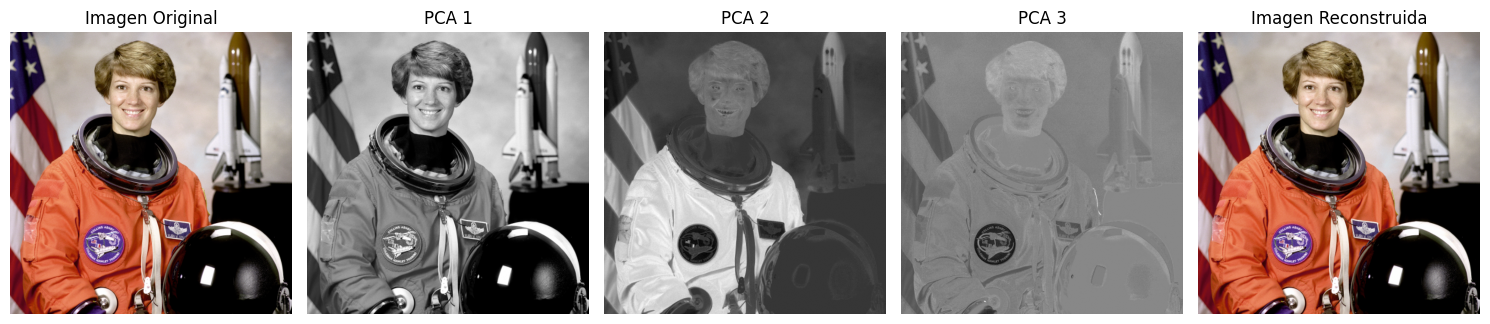

In [5]:
from skimage import data

# Cargar la imagen de entrada y normalizarla
image = data.astronaut() / 255.0

# Convertir la imagen a un array 2D donde cada fila es un píxel y cada columna es un canal de color
image_reshaped = image.reshape(-1, 3)

# Aplicar PCA para extraer sus componentes principales
pca = PCA()
image_pca = pca.fit_transform(image_reshaped)
image_components = image_pca.reshape(image.shape[0], image.shape[1], -1)

# Reconstruir la imagen a partir de sus componentes principales
reconstructed_image = pca.inverse_transform(image_pca).reshape(image.shape)

# Clip los valores para asegurarse de que estén en el rango [0, 1]
reconstructed_image = np.clip(reconstructed_image, 0, 1)

# Mostrar las imágenes obtenidas
plt.figure(figsize=(15, 5))
plt.subplot(1, 5, 1); plt.imshow(image); plt.title('Imagen Original'); plt.axis('off')
plt.subplot(1, 5, 2); plt.imshow(image_components[...,0], cmap='gray'); plt.title('PCA 1'); plt.axis('off')
plt.subplot(1, 5, 3); plt.imshow(image_components[...,1], cmap='gray'); plt.title('PCA 2'); plt.axis('off')
plt.subplot(1, 5, 4); plt.imshow(image_components[...,2], cmap='gray'); plt.title('PCA 3'); plt.axis('off')
plt.subplot(1, 5, 5); plt.imshow(reconstructed_image); plt.title('Imagen Reconstruida'); plt.axis('off')
plt.tight_layout()
plt.show()

Al descomponer la imagen original en sus componentes principales, podemos observar cómo cada uno captura diferentes aspectos de la información visual. El componente PCA 1, que es el de mayor varianza, se corresponde con los detalles más prominentes y contrastados de la imagen, mientras que el resto capturan detalles más sutiles. La alta fidelidad de la imagen reconstruida con respecto a la original evidencia la efectividad del PCA para la reducción de dimensionalidad y la compresión de imágenes.

### Agrupamiento (clustering)

El agrupamiento ([clustering](https://en.wikipedia.org/wiki/Cluster_analysis)) es una técnica de aprendizaje no supervisado que clasifica los datos en clústeres en base a sus similitudes. La capacidad de extraer la estructura subyacente de los datos hace del clustering una herramienta fundamental en el procesamiento de imágenes, permitiendo aplicaciones como la compresión, segmentación y mejora de la caracterización visual, entre muchas otras. A continuación, revisaremos algunas aplicaciones relevantes.

#### Cuantización de Imágenes con K-means

La cuantización de imágenes mediante clustering busca agrupar píxeles similares y reemplazarlos con el color promedio del clúster, permitiendo así la compresión y facilitando su análisis. Uno de los métodos de agrupamiento más utilizados es [K-means](https://en.wikipedia.org/wiki/K-means_clustering), el cual divide los datos en *k* clústeres, asignando cada muestra al clúster más cercano a su centroide. El proceso se realiza de forma iterativa, recalculando los centroides y reasignando los puntos hasta estabilizar las asignaciones, con el objetivo de minimizar la variación dentro de los clústeres y maximizar la separación entre ellos. El siguiente ejemplo muestra cómo utilizar el algoritmo K-means de *scikit-learn* para reducir el número de colores de una imagen dada.

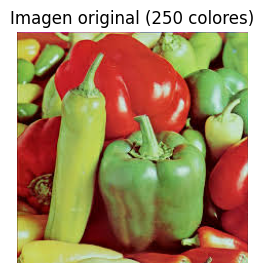

K-means con 64 colores terminado en 0.560s.
Predicción de índices de color terminada en 0.567s.
K-means con 32 colores terminado en 0.079s.
Predicción de índices de color terminada en 0.079s.
K-means con 16 colores terminado en 0.054s.
Predicción de índices de color terminada en 0.054s.
K-means con 4 colores terminado en 0.035s.
Predicción de índices de color terminada en 0.037s.


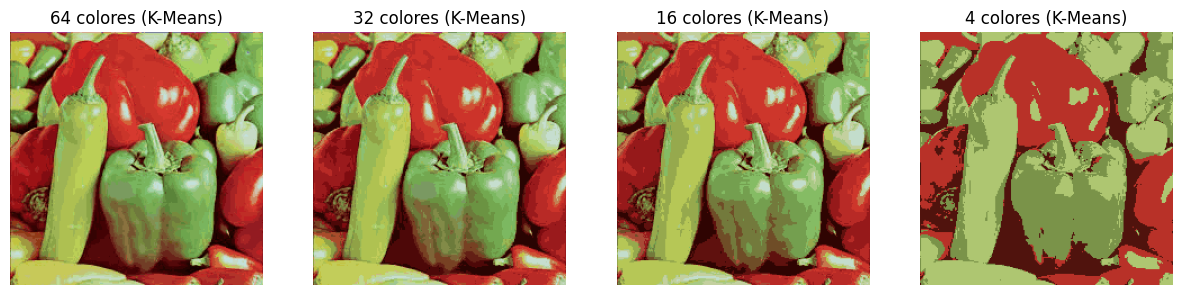

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage.io import imread
from skimage import img_as_float
from sklearn.utils import shuffle
from time import time

# Cargar la imagen RGB
pepper = imread("images/pepper.jpg")

# Mostrar la imagen original
plt.figure(figsize=(3, 3))
plt.imshow(pepper)
plt.title(f'Imagen original ({len(np.unique(pepper))} colores)')
plt.axis('off')
plt.show()

# Número de colores para la cuantización
n_colors = 64

# Convertir a flotantes y normalizar
pepper = img_as_float(pepper)

# Transformar la imagen en un array 2D
w, h, d = pepper.shape
image_array = np.reshape(pepper, (w * h, d))

def recreate_image(codebook, labels, w, h):
    """Crear la imagen cuantizada a partir del código y las etiquetas"""
    d = codebook.shape[1]
    image = np.zeros((w, h, d))
    for i in range(w):
        for j in range(h):
            image[i, j] = codebook[labels[i * h + j]]
    return image

# Mostrar la imagen original y todos los resultados de la cuantización
plt.figure(figsize=(15, 5))
for i, k in enumerate([64, 32, 16, 4], start=1):
    t0 = time()
    plt.subplot(1, 4, i)
    plt.axis('off')
    image_array_sample = shuffle(image_array, random_state=0)[:1000] # muestra aleatoria de 1000 píxeles para acelerar el cálculo
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(image_array_sample)
    print(f"K-means con {k} colores terminado en {time() - t0:.3f}s.")
    # Obtener etiquetas para todos los puntos
    labels = kmeans.predict(image_array)
    print(f"Predicción de índices de color terminada en {time() - t0:.3f}s.")
    plt.title(f'{k} colores (K-Means)', size=12)
    plt.imshow(recreate_image(kmeans.cluster_centers_, labels, w, h))
plt.show()

Los resultados muestran cómo la imagen se degrada gradualmente al considerar menos colores, pero mantiene suficiente información visual sobre las regiones más relevantes de la imagen al aplicar el agrupamiento.


#### Clustering Espectral para Segmentación

El [clustering espectral](https://en.wikipedia.org/wiki/Spectral_clustering) es una técnica avanzada de agrupamiento que transforma los datos originales para capturar la estructura de los grupos en el espacio de los vectores propios del laplaciano de la matriz de similitud de los datos. Este proceso identifica puntos de inflexión entre las similitudes de las muestras, permitiendo detectar regiones y estructuras intrínsecas en los datos, especialmente en casos complejos. A continuación, se presenta un ejemplo de uso para segmentación.

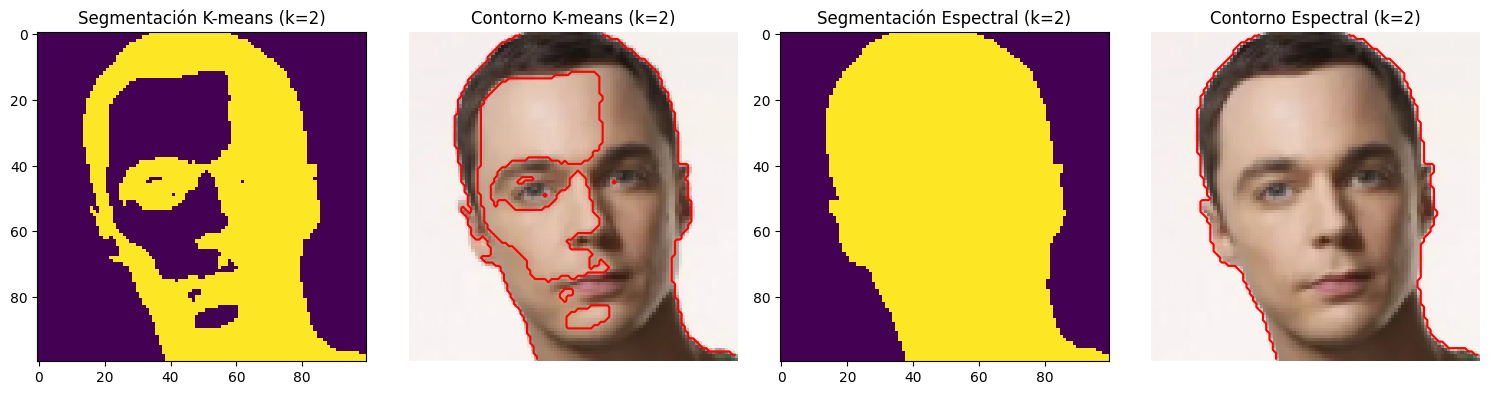

In [7]:
from sklearn import cluster
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np

# Cargar y redimensionar la imagen
im = resize(imread('images/sheldon.jpg'), (100, 100, 3), anti_aliasing=True)
img_gray = rgb2gray(im)

# Parámetro k para la segmentación binaria
k = 2

# Convertir la imagen a un array 2D
X = np.reshape(im, (-1, im.shape[-1]))

# Aplicar K-means
kmeans = cluster.MiniBatchKMeans(n_clusters=k, random_state=0, n_init=10)
kmeans.fit(X)
kmeans_labels = kmeans.predict(X)
kmeans_labels_reshaped = np.reshape(kmeans_labels, im.shape[:2])

# Aplicar Clustering Espectral
spectral = cluster.SpectralClustering(n_clusters=k, random_state=0, affinity="nearest_neighbors")
spectral.fit(X)
spectral_labels = spectral.labels_.astype(int)
spectral_labels_reshaped = np.reshape(spectral_labels, im.shape[:2])

# Figura para mostrar los resultados
plt.figure(figsize=(15, 5))

# Mostrar resultados de K-means
plt.subplot(141)
plt.imshow(kmeans_labels_reshaped)
plt.title('Segmentación K-means (k=2)', size=12)
plt.subplot(142)
plt.imshow(im)
plt.contour(kmeans_labels_reshaped == 0, colors='red')
plt.axis('off')
plt.title('Contorno K-means (k=2)', size=12)

# Mostrar resultados de Clustering Espectral
plt.subplot(143)
plt.imshow(spectral_labels_reshaped)
plt.title('Segmentación Espectral (k=2)', size=12)
plt.subplot(144)
plt.imshow(im)
plt.contour(spectral_labels_reshaped == 0, colors='red')
plt.axis('off')
plt.title('Contorno Espectral (k=2)', size=12)

plt.tight_layout()
plt.show()

Como podemos observar, el clustering espectral diferencia mejor entre el primer plano y el fondo debido a su capacidad para identificar estructuras globales en los datos, mientras que K-means tiende a confundir regiones con tonos de color similares, resultando en una segmentación menos precisa.

<div style="page-break-before: always;"></div>

____
 <a class='anchor' id='supervisado12'></a>
 
## Aprendizaje Supervisado

El [aprendizaje supervisado](https://en.wikipedia.org/wiki/Supervised_learning) consiste en utilizar datos etiquetados para entrenar modelos que puedan realizar tareas de clasificación o predicción con alta precisión. En el contexto del procesamiento de imágenes y la visión por computadora, este enfoque permite que los algoritmos aprendan de ejemplos de entrenamiento y generalicen a nuevas imágenes no vistas previamente. En este apartado, revisaremos algunas técnicas relevantes y su aplicación práctica.

### Clasificación de Imágenes

Antes de entrenar cualquier modelo de clasificación, es necesario cargar y preparar adecuadamente el conjunto de datos. En este apartado utilizaremos [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist), un conjunto de imágenes en escala de grises que se emplea habitualmente en ejemplos básicos y ejercicios introductorios de visión por computador. Cada imagen representa una prenda de vestir y está asociada a una etiqueta que indica su categoría. A continuación, cargaremos el conjunto de datos, lo normalizaremos y mostraremos algunas imágenes de ejemplo para familiarizarnos con el tipo de información con la que trabajaremos.

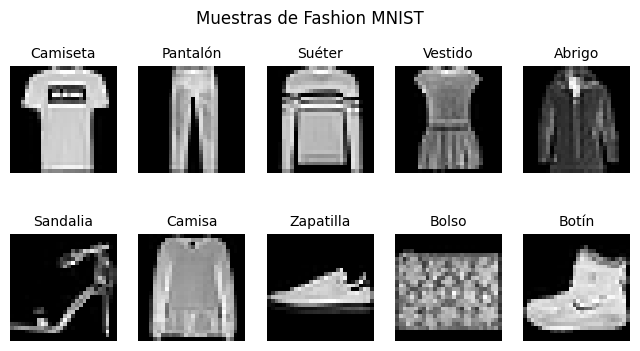

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Cargar Fashion MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalizar a rango [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# Mostrar una imagen por clase
def plot_sample_images(X, y, class_names, title):
    plt.figure(figsize=(8, 4))
    for i in range(len(class_names)):
        idx = np.where(y == i)[0][0]
        plt.subplot(2, len(class_names)//2, i + 1)
        plt.imshow(X[idx], cmap='gray')
        plt.axis('off')
        plt.title(class_names[i], size=10)
    plt.suptitle(title, size=12)
    plt.show()

class_names = ["Camiseta", "Pantalón", "Suéter", "Vestido", "Abrigo",
               "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"]

plot_sample_images(X_train, y_train, class_names, "Muestras de Fashion MNIST")

Una vez preparado el conjunto de datos, podemos aplicar algoritmos clásicos de aprendizaje supervisado para abordar la clasificación de las imágenes. En este apartado emplearemos dos métodos bien establecidos: K-Nearest Neighbors ([KNN](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm)) y Support Vector Machines ([SVM](https://en.wikipedia.org/wiki/Support_vector_machine)). Ambos modelos se entrenan utilizando un subconjunto representativo de imágenes etiquetadas y posteriormente se evalúan sobre un conjunto de prueba formado por imágenes nunca vistas durante el entrenamiento, lo que permite medir de forma fiable su capacidad de generalización. Tras ajustar los clasificadores, analizaremos su rendimiento mediante informes de clasificación y matrices de confusión, y visualizaremos algunas predicciones para interpretar mejor los resultados obtenidos.

Entrenando KNN...
Entrenando SVM...
Evaluando en el conjunto de test...
Informe de clasificación KNN:
               precision    recall  f1-score   support

    Camiseta       0.71      0.81      0.76      1000
    Pantalón       0.98      0.93      0.96      1000
      Suéter       0.62      0.71      0.67      1000
     Vestido       0.86      0.80      0.83      1000
      Abrigo       0.73      0.64      0.68      1000
    Sandalia       0.99      0.76      0.86      1000
      Camisa       0.53      0.53      0.53      1000
   Zapatilla       0.84      0.92      0.88      1000
       Bolso       0.97      0.92      0.94      1000
       Botín       0.84      0.96      0.90      1000

    accuracy                           0.80     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.81      0.80      0.80     10000



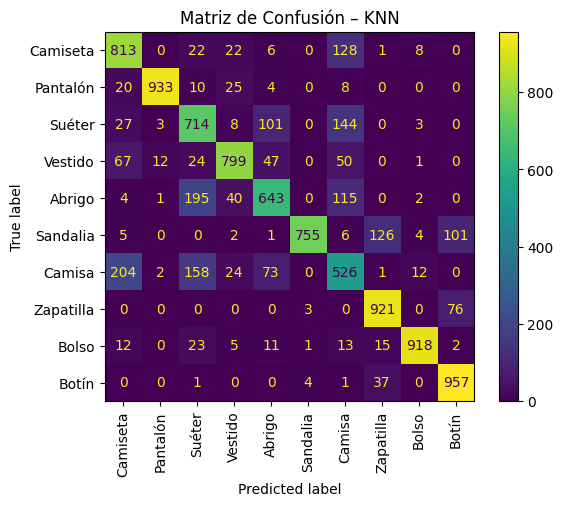

Informe de clasificación SVM:
               precision    recall  f1-score   support

    Camiseta       0.73      0.80      0.76      1000
    Pantalón       0.96      0.95      0.95      1000
      Suéter       0.65      0.73      0.69      1000
     Vestido       0.82      0.81      0.82      1000
      Abrigo       0.72      0.66      0.69      1000
    Sandalia       0.90      0.90      0.90      1000
      Camisa       0.56      0.49      0.52      1000
   Zapatilla       0.88      0.90      0.89      1000
       Bolso       0.94      0.92      0.93      1000
       Botín       0.92      0.91      0.92      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



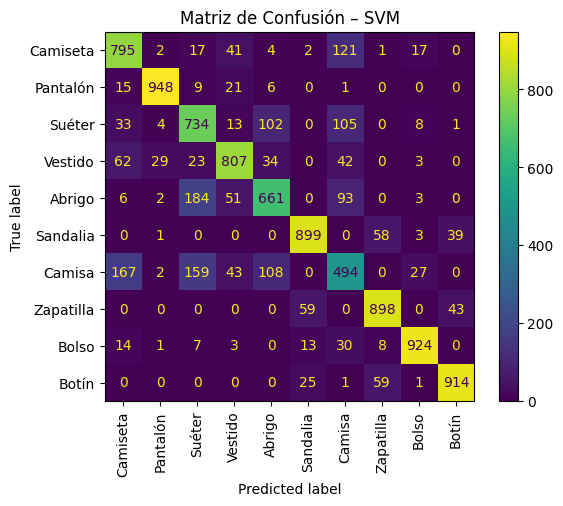

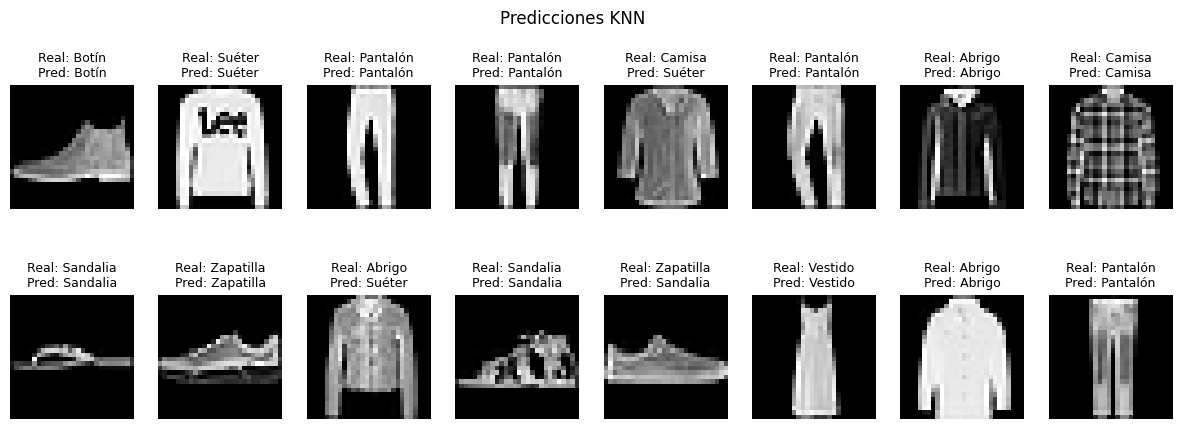

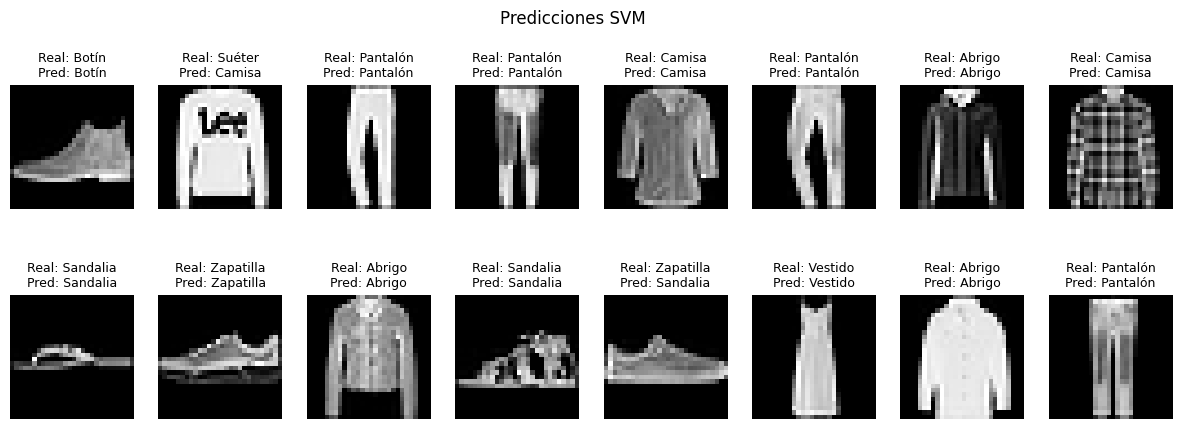

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Reducir tamaño del conjunto para entrenar más rápido
X_train_small, _, y_train_small, _ = train_test_split( X_train, y_train, train_size=0.1, stratify=y_train, random_state=42)

# Aplanar imágenes
X_train_small = X_train_small.reshape(X_train_small.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Entrenamiento (train)
print("Entrenando KNN...")
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_small, y_train_small)

print("Entrenando SVM...")
svm = SVC(kernel='linear')
svm.fit(X_train_small, y_train_small)

# Evaluación (test)
print("Evaluando en el conjunto de test...")
y_pred_knn = knn.predict(X_test_flat)
y_pred_svm = svm.predict(X_test_flat)

print("Informe de clasificación KNN:\n", classification_report(y_test, y_pred_knn, target_names=class_names))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, display_labels=class_names, xticks_rotation='vertical')
plt.title("Matriz de Confusión – KNN")
plt.show()

print("Informe de clasificación SVM:\n", classification_report(y_test, y_pred_svm, target_names=class_names))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, display_labels=class_names, xticks_rotation='vertical')
plt.title("Matriz de Confusión – SVM")
plt.show()

# Visualización de predicciones
def plot_images(images, labels_true, labels_pred, title, num_imgs=16):
    plt.figure(figsize=(15, 5))
    for i in range(num_imgs):
        plt.subplot(2, 8, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f'Real: {class_names[labels_true[i]]}\nPred: {class_names[labels_pred[i]]}', size=9)
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

plot_images(X_test[:16], y_test[:16], y_pred_knn[:16], "Predicciones KNN")
plot_images(X_test[:16], y_test[:16], y_pred_svm[:16], "Predicciones SVM")

Los resultados muestran que tanto KNN como SVM alcanzan alrededor de un 80 por ciento de acierto en el conjunto de prueba, un valor razonable si se tiene en cuenta que las imágenes se han representado mediante una simple vectorización de los píxeles. Algunas clases resultan más fáciles de distinguir que otras, como *Pantalón* o *Botín*, mientras que categorías más parecidas entre sí, como *Camiseta*, *Suéter* o *Camisa*, generan un mayor número de errores. Las matrices de confusión y las predicciones visualizadas ayudan a identificar estos patrones. Este ejemplo demuestra que los métodos supervisados clásicos pueden generalizar de forma aceptable en escenarios básicos, aunque imágenes más complejas requerirán técnicas de caracterización más avanzadas para capturar de forma efectiva los patrones visuales presentes en ellas.

### Regresión de Imágenes

Así como la clasificación busca predecir etiquetas, el problema de regresión se centra en estimar uno o más valores numéricos a partir de una imagen de entrada. Muchas tareas de visión por computador pueden formularse de este modo. En este apartado trabajaremos con un ejemplo básico de [súper resolución](https://en.wikipedia.org/wiki/Super-resolution_imaging) utilizando el conjunto de imágenes Fashion MNIST empleado anteriormente. El objetivo es reconstruir una versión de mayor calidad a partir de una imagen previamente degradada. Para ello emplearemos una pequeña red neuronal convolucional que toma como entrada las imágenes de baja resolución y aprende a predecir su versión mejorada. Este ejemplo permite observar cómo una CNN es capaz de aproximar patrones espaciales y detalles visuales mediante un proceso de regresión sobre los valores de los píxeles.

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.1001 - val_loss: 0.0370
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0251 - val_loss: 0.0190
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0157 - val_loss: 0.0142
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0134 - val_loss: 0.0128
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0120 - val_loss: 0.0120
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0111 - val_loss: 0.0111
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0104 - val_loss: 0.0106
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0099 - val_loss: 0.0100
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0094 - val_loss: 0.0096
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0090 - val_loss: 0.0095
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0088 - val_loss: 0.0091
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0

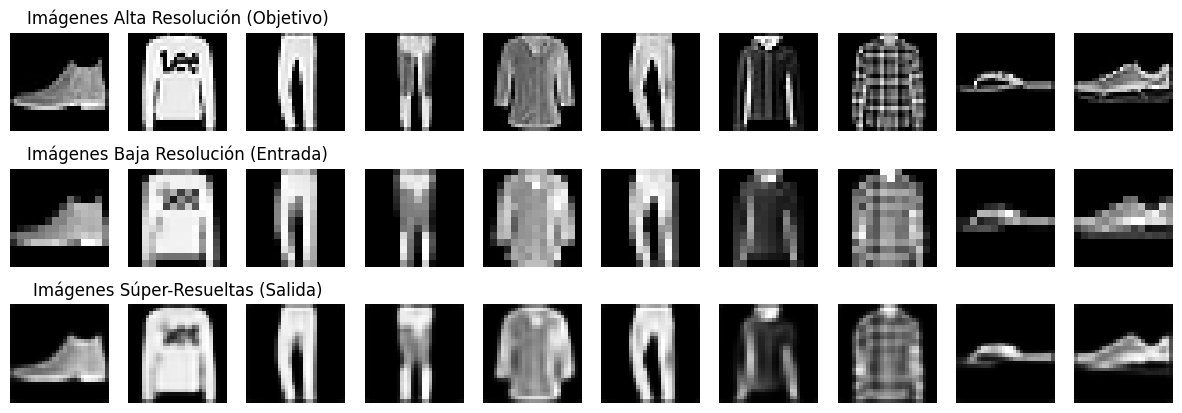

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, UpSampling2D, Conv2D
from tensorflow.keras.datasets import fashion_mnist

# Cargar y preprocesar los datos Fashion MNIST
(X_train, _), (X_test, _) = fashion_mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Limitamos el numero de muestras para un entrenamiento más rápido
X_train = X_train[:1000]

# Asegurarse de que las imágenes tengan una dimensión de canal
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# Reducir la resolución de las imágenes
low_res_X_train = tf.image.resize(X_train, [14, 14])
low_res_X_test = tf.image.resize(X_test, [14, 14])

# Definir el modelo de súper-resolución
model = Sequential([
    InputLayer(shape=(14, 14, 1)),                        # capa de entrada (imagen baja resolución)
    UpSampling2D(size=(2, 2)),                                  # interpolación inicial
    Conv2D(64, (9, 9), activation='relu', padding='same'),      # primera capa de convolución
    Conv2D(32, (1, 1), activation='relu', padding='same'),      # segunda capa de convolución
    Conv2D(1,  (5, 5), activation='sigmoid', padding='same')    # salida (imagen de alta resolución)
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse')

# Entrenar el modelo
model.fit(low_res_X_train, X_train, epochs=20, batch_size=32, validation_data=(low_res_X_test, X_test))

# Evaluar el modelo en algunas imágenes de prueba
num_tests = 10
low_res_test_imgs = low_res_X_test[:num_tests]
high_res_test_imgs = model.predict(low_res_test_imgs)

# Mostrar los resultados
def plot_comparison(low_res, high_res, generated):
    num_images = low_res.shape[0]
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(3, num_images, i + 1)
        plt.imshow(high_res[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if i == 1:
            plt.title('Imágenes Alta Resolución (Objetivo)', fontsize=12)
        
        plt.subplot(3, num_images, i + num_images + 1)
        plt.imshow(low_res[i].numpy().reshape(14, 14), cmap='gray')
        plt.axis('off')
        if i == 1:
            plt.title('Imágenes Baja Resolución (Entrada)', fontsize=12)
        
        plt.subplot(3, num_images, i + 2*num_images + 1)
        plt.imshow(generated[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if i == 1:
            plt.title('Imágenes Súper-Resueltas (Salida)', fontsize=12)
    
    plt.show()

plot_comparison(low_res_test_imgs, X_test[:num_tests], high_res_test_imgs)

El resultado muestra cómo la red convolucional es capaz de mejorar notablemente la calidad visual de las imágenes a partir de sus versiones degradadas. Aunque la súper resolución obtenida no recupera todos los detalles finos del objetivo original, sí reconstruye contornos más suaves y formas más definidas que la imagen de entrada. Esto ilustra cómo una CNN sencilla puede aprender a aproximar estructuras espaciales básicas y generar imágenes de mayor calidad a partir de información limitada.

<div style="page-break-before: always;"></div>

___
 <a class='anchor' id='ejercicios12'></a>

## Ejercicios de práctica

### *Ejercicio 1. Conteo de Árboles*

En este ejercicio, implementarás un programa en Python para detectar y contar árboles en una imagen aérea utilizando la técnica de coincidencia de plantillas (template matching). Comienza cargando la imagen `images/trees.jpg` y encárgate de procesarla adecuadamente. Luego, selecciona manualmente una región de la imagen que contenga un árbol para usarla como plantilla. Seguidamente, aplica el método de coincidencia de plantillas de *OpenCV* para buscar áreas en la imagen que se asemejen a la plantilla del árbol. Establece un umbral adeacuado para lograr alcanzar todas detecciones y aplica la técnica de supresión de no máximos (Non-Maximum Suppression) para eliminar las detecciones redundantes, es decir, aquellas que están demasiado cerca unas de otras y representan el mismo árbol. Finalmente, dibuja rectángulos alrededor de las detecciones restantes y muestra la imagen original junto con la imagen que contiene los árboles detectados, indicando su número total.


<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="images/ej1_trees.jpg" style="width:60%; height:auto; margin-right: 50px;">
</div>
<br><br>

(np.float64(-0.5), np.float64(409.5), np.float64(345.5), np.float64(-0.5))

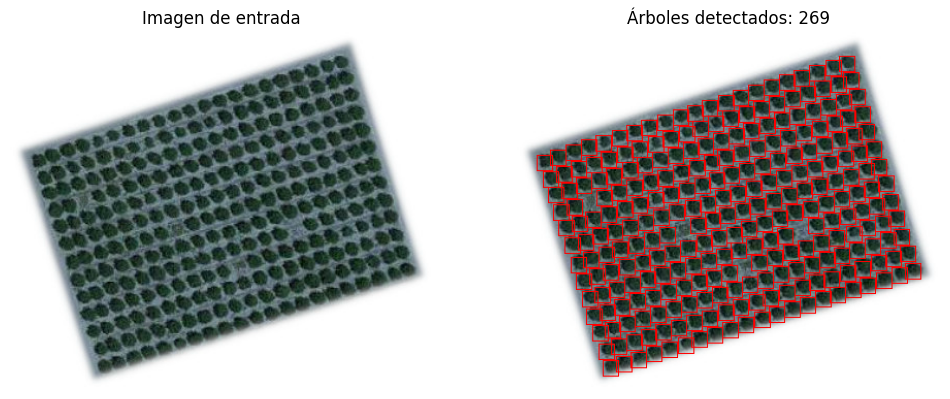

In [11]:
imagen_original = cv2.imread("images/trees.jpg")
imagen = cv2.imread("images/trees.jpg")
imagen_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

template = imagen_gray[223:238, 148:163]
w, h = template.shape[::-1]

result2 = cv2.matchTemplate(imagen_gray, template, cv2.TM_CCOEFF_NORMED)

threshold = 0.56
# Buscar coincidencias con el umbral definido anteriormente
ys, xs = np.where(result2 >= threshold)

# Crear una lista de las cajas delimitadoras y sus scores
boxes = []
scores = []
for x, y in zip(xs, ys):
    boxes.append([x, y, w, h])
    scores.append(result2[y, x])

# Aplicar la supresión de no máximos
indices = cv2.dnn.NMSBoxes(boxes, scores, score_threshold=threshold, nms_threshold=0.3)

# Dibujar rectángulos alrededor de las coincidencias después de la supresión de no máximos
for i in indices:
    box = boxes[i]
    top_left = (box[0], box[1])
    bottom_right = (box[0] + box[2], box[1] + box[3])
    cv2.rectangle(imagen, top_left, bottom_right, (255, 0, 0), 1)

# Mostrar la imagen resultante con las coincidencias marcadas
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharex=True, sharey=True)

axes[0].imshow(imagen_original)
axes[0].set_title('Imagen de entrada')
axes[0].axis('off')
axes[1].imshow(imagen)
axes[1].set_title(f'Árboles detectados: {len(indices)}')
axes[1].axis('off')


### *Ejercicio 2. Fusión de Imágenes*

Desarrolla un programa en Python para realizar la fusión de imágenes utilizando el Análisis de Componentes Principales (PCA). Comienza cargando dos imágenes de la misma escena: una imagen a color de baja resolución (`images/guepard_small_rgb.jpg`) y una imagen en blanco y negro de alta resolución (`images/guepard_big_bw.jpg`). Si lo consideras oportuno, puedes normalizar los valores de los píxeles dividiendo por 255. A continuación, aplica el PCA en la imagen a color de baja resolución para transformar los datos en sus componentes principales. Después, interpola los componentes principales a la resolución de la imagen en blanco y negro de alta resolución y reemplaza el primer componente principal interpolado con la imagen en blanco y negro de alta resolución. Posteriormente, reconstruye la imagen a color a partir de los componentes principales modificados utilizando la transformación inversa del PCA. Asegúrate de que los valores de los píxeles de la imagen reconstruida estén en el rango inicial. Finalmente, ecualiza la imagen fusionada para que coincida con la imagen a color de baja resolución y visualiza las imágenes originales y la imagen fusionada en una sola figura.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="images/ej2_guepard.jpg" style="width:80%; height:auto; margin-right: 50px;">
</div>
<br><br>

(480, 612)


c:\Users\cgeal\Desktop\Asignaturas\.venv311\Lib\site-packages\skimage\_shared\utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


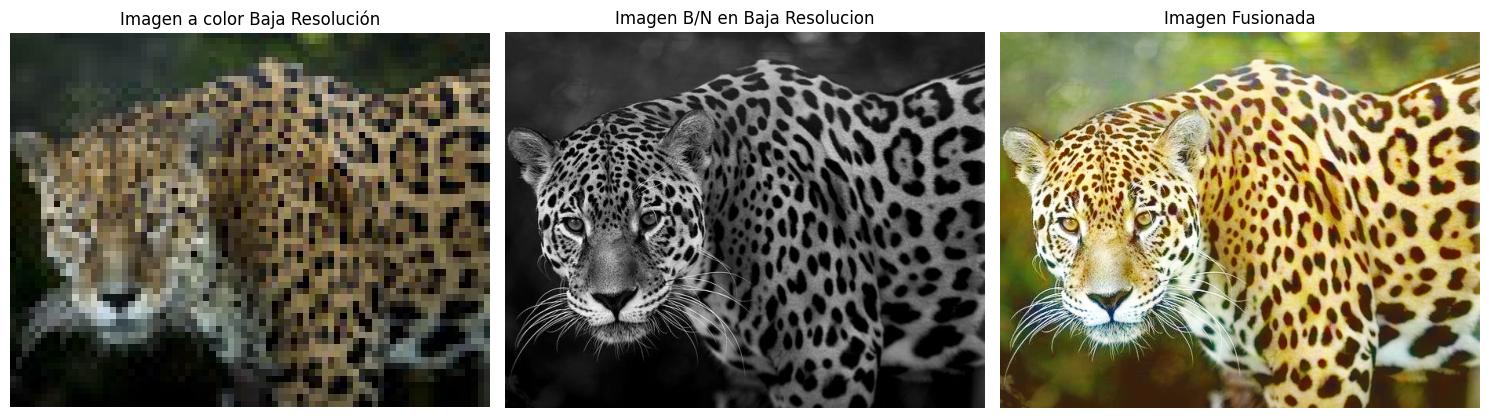

In [12]:
from skimage.transform import resize
from skimage import exposure

imagen_baja = cv2.cvtColor(cv2.imread("images/guepard_small_rgb.jpg"), cv2.COLOR_BGR2RGB)/255.0 # PASAR A RGB DE BGR
imagen_gris = cv2.imread("images/guepard_big_bw.jpg")/255.0
imagen_gris = imagen_gris[:, :, 0]

print(imagen_gris.shape)
# Convertir la imagen a un array 2D donde cada fila es un píxel y cada columna es un canal de color
image_reshaped = imagen_baja.reshape(-1, 3)

# Aplicar PCA para extraer sus componentes principales
pca = PCA()
image_pca = pca.fit_transform(image_reshaped)
image_components = image_pca.reshape(imagen_baja.shape[0], imagen_baja.shape[1], -1)

# Interpolamos con resize
image_components = resize(image_components, (imagen_gris.shape[0], imagen_gris.shape[1], 3), anti_aliasing=True)

image_components[:, :, 0] = imagen_gris 

image_reconstructed = image_components.reshape(-1, 3)

# Reconstruir la imagen a partir de sus componentes principales
reconstructed_image = pca.inverse_transform(image_reconstructed).reshape((imagen_gris.shape[0], imagen_gris.shape[1], 3))

# Clip los valores para asegurarse de que estén en el rango [0, 1]
reconstructed_image = np.clip(reconstructed_image, 0, 1)

ecualizada = exposure.equalize_hist(reconstructed_image)

# Mostrar las imágenes obtenidas
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(imagen_baja); plt.title('Imagen a color Baja Resolución'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(imagen_gris, cmap='gray'); plt.title('Imagen B/N en Baja Resolucion'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(ecualizada); plt.title('Imagen Fusionada'); plt.axis('off')
plt.tight_layout()
plt.show()

### *Ejercicio 3. Análisis de Centroides*

Implementa un programa en Python para explorar cómo el tamaño de la muestra de datos afecta a los centroides obtenidos mediante el algoritmo de agrupamiento *KMeans*. Comienza cargando el conjunto de imágenes `Fashion MNIST` y prepara los datos para el clustering. A continuación, selecciona diferentes tamaños de muestras en orden creciente (100, 1000, 10000 y todas las muestras disponibles). Para cada tamaño, aplica *KMeans* con 10 clusters y visualiza los centroides resultantes en una figura, mostrando una fila de centroides para cada tamaño de muestra. Asegúrate de etiquetar claramente cada fila con el tamaño de la muestra correspondiente y cada columna con el número del cluster, para observar cómo varían los centroides con el tamaño de la muestra. Finalmente, reflexiona sobre las siguientes cuestiones: ¿Por qué los centroides van cambiando en cada ejecución? ¿Puedes identificar todas las clases en la última ejecución? Si no es así, indica qué clases observas que se están confundiendo y cuáles están sobrerrepresentadas a la vista de los centroides, y explica por qué.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="images/ej3_centroids.jpg" style="width:80%; height:auto; margin-right: 50px;">
</div>
<br><br>

Cargando datos...
Total de muestras de entrenamiento: 60000
Dimensiones de cada imagen: 28x28

Procesando tamaño de muestra: 100
KMeans con 100 muestras terminado en 0.212s

Procesando tamaño de muestra: 1000
KMeans con 1000 muestras terminado en 0.681s

Procesando tamaño de muestra: 10000
KMeans con 10000 muestras terminado en 7.170s

Procesando tamaño de muestra: 60000
KMeans con 60000 muestras terminado en 47.627s

Figura guardada como 'kmeans_fashion_mnist_result.png'

--- Reflexión ---
1. ¿Por qué los centroides van cambiando en cada ejecución?
   Los centroides cambian porque al aumentar el tamaño de la muestra, el algoritmo tiene más información sobre la distribución real de los datos. Con pocas muestras (100), los centroides se ven muy ruidosos y se ajustan a un subconjunto específico. A medida que N aumenta, los centroides convergen a formas más nítidas y representativas de las clases promedio.

2. ¿Puedes identificar todas las clases en la última ejecución?
   Se pueden ident

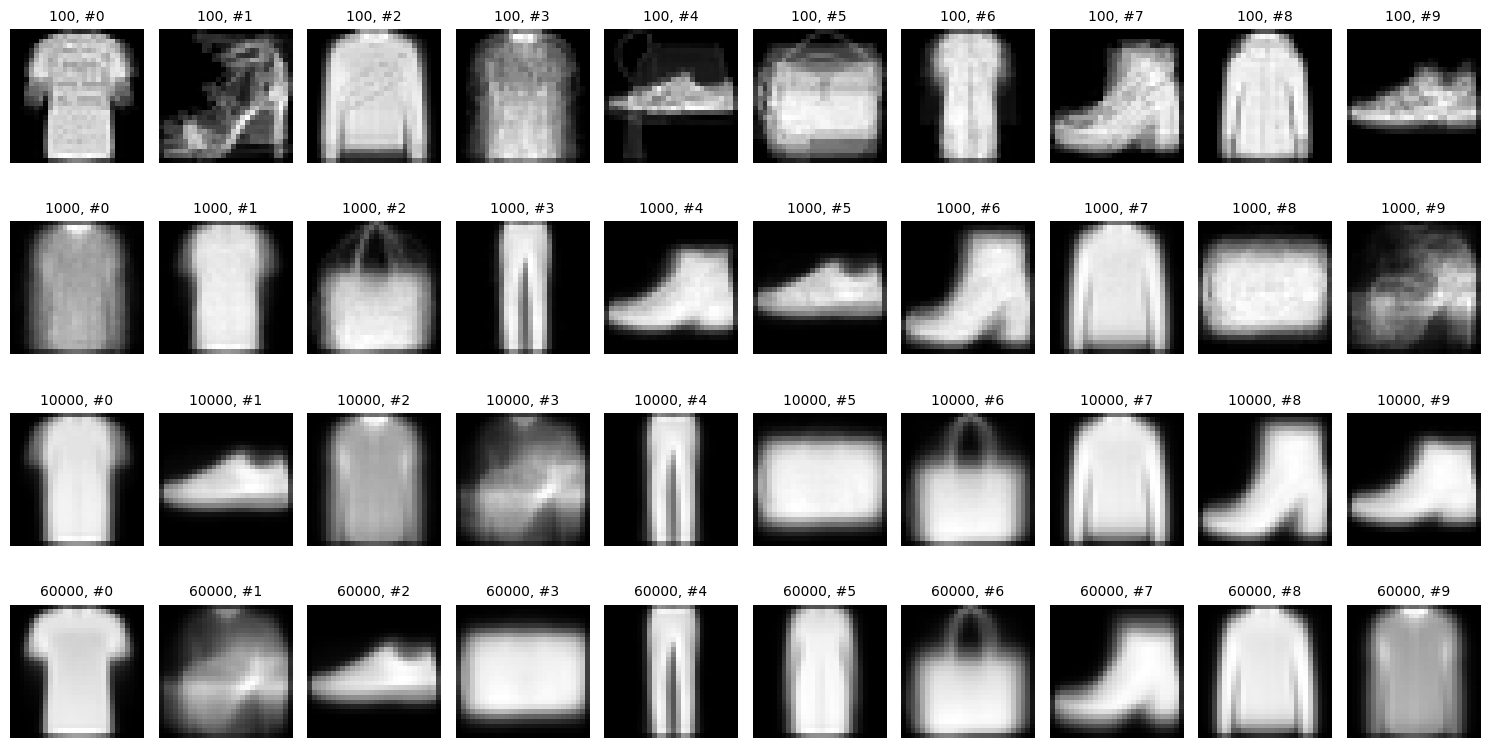

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from time import time

# 1. Cargar y preparar datos
print("Cargando datos...")
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalizar a rango [0, 1]
X_train = X_train.astype('float32') / 255.0
n_samples, h, w = X_train.shape

# Aplanar las imágenes para KMeans (n_samples, 784)
X_train_flat = X_train.reshape(n_samples, h * w)

# Tamaños de muestra a probar
sample_sizes = [100, 1000, 10000, n_samples]
n_clusters = 10

print(f"Total de muestras de entrenamiento: {n_samples}")
print(f"Dimensiones de cada imagen: {h}x{w}")

plt.figure(figsize=(15, 8))

for i, size in enumerate(sample_sizes):
    print(f"\nProcesando tamaño de muestra: {size}")
    t0 = time()
    
    # Seleccionar muestra
    if size == n_samples:
        X_sample = X_train_flat
    else:
        # Usar shuffle para obtener una muestra aleatoria
        X_sample = shuffle(X_train_flat, random_state=0)[:size]
        
    # Aplicar KMeans
    # n_init='auto' o un número fijo (ej. 10) para evitar warnings en versiones recientes
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
    kmeans.fit(X_sample)
    
    dt = time() - t0
    print(f"KMeans con {size} muestras terminado en {dt:.3f}s")
    
    # Visualizar centroides
    # Los centroides están en el espacio aplanado (784,), hay que redimensionarlos a (28, 28)
    centroids = kmeans.cluster_centers_.reshape(n_clusters, h, w)
    
    for j in range(n_clusters):
        # Crear subplot: filas = len(sample_sizes), cols = n_clusters
        ax = plt.subplot(len(sample_sizes), n_clusters, i * n_clusters + j + 1)
        plt.imshow(centroids[j], cmap='gray')
        plt.axis('off')
        
        plt.title(f'{size}, #{j}', fontsize=10)

plt.tight_layout()
# Guardar la figura para verificar si se generó correctamente (opcional, pero buena práctica en modo headless)
plt.savefig('kmeans_fashion_mnist_result.png')
print("\nFigura guardada como 'kmeans_fashion_mnist_result.png'")
# plt.show() # No bloquear la ejecución

# Reflexión
print("\n--- Reflexión ---")
print("1. ¿Por qué los centroides van cambiando en cada ejecución?")
print("   Los centroides cambian porque al aumentar el tamaño de la muestra, el algoritmo tiene más información sobre la distribución real de los datos. Con pocas muestras (100), los centroides se ven muy ruidosos y se ajustan a un subconjunto específico. A medida que N aumenta, los centroides convergen a formas más nítidas y representativas de las clases promedio.")

print("\n2. ¿Puedes identificar todas las clases en la última ejecución?")
print("   Se pueden identificar varias prendas (camisetas, pantalones, zapatillas, bolsos), pero no necesariamente las 10 clases exactas de Fashion MNIST. KMeans agrupa por similitud visual (distancia euclidiana), no semántica.")

print("\n3. Clases confundidas o sobrerrepresentadas:")
print("   - Confundidas: Prendas con formas similares como 'Pullover', 'Coat' y 'Shirt' a menudo se mezclan en centroides similares.")
print("   - Sobrerrepresentadas: Si una clase tiene mucha variabilidad visual, KMeans podría asignarle más de un cluster. Por ejemplo, pantalones claros vs oscuros, o diferentes tipos de calzado.")
